# Simple example

The smallest end-to-end calculation: take a **primordial curvature power spectrum**
$\mathcal{P}_\zeta(k)$, pick a **kernel** (the transfer function for the source era), and
get the **induced GW spectrum** $\Omega_{\mathrm{GW}}(f)$.

In SIGWAY those are three objects composed into one `OmegaGW` model.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # SIGW integrals need float64
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Figures: vector (SVG), transparent, theme-neutral so they read on
# both the light and dark documentation themes. (Set once.)
%config InlineBackend.figure_formats = ["svg"]
plt.rcParams.update({
    "figure.figsize": (6.2, 3.6),
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "axes.edgecolor": "#8a8fa3", "axes.labelcolor": "#8a8fa3",
    "xtick.color": "#8a8fa3", "ytick.color": "#8a8fa3",
    "text.color": "#8a8fa3",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=["#3a8cc4", "#e0455c", "#20305f"]),
})

from sigway.spectrum import OmegaGW
from sigway.kernels import RadiationKernel
from sigway.perturbations import AnalyticPerturbations

## 1. A primordial power spectrum

We use a **log-normal peak** — a bump of curvature power on a characteristic scale
$k_\star$, with three knobs:

| param      | meaning                                            |
|------------|----------------------------------------------------|
| `logAs`    | $\log_{10}$ of the integrated amplitude $A_s$      |
| `logDelta` | $\log_{10}$ of the dimensionless width $\Delta$    |
| `logks`    | $\log_{10}$ of the peak wavenumber $k_\star$       |

$$\mathcal{P}_\zeta(k) = \frac{A_s}{\sqrt{2\pi}\,\Delta}\,
\exp\!\left[-\frac{\ln^2(k/k_\star)}{2\Delta^2}\right].$$

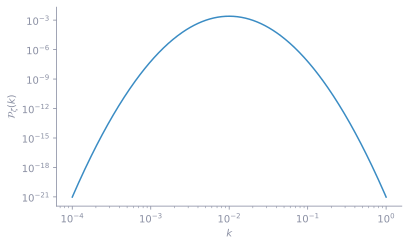

In [2]:
def pzeta_lognormal(k, logAs, logDelta, logks):
    As = 10.0**logAs
    Delta = 10.0**logDelta
    ks = 10.0**logks
    norm = As / (jnp.sqrt(2*jnp.pi) * Delta)
    return norm * jnp.exp(-0.5/Delta**2 * jnp.log(k/ks)**2)

params = (-2.5, -0.30103, -2.0)   # logAs, logDelta, logks  (peak at k_*=0.01)

k = jnp.geomspace(1e-4, 1e0, 400)
plt.loglog(k, pzeta_lognormal(k, *params))
plt.xlabel("$k$")
plt.ylabel(r"$\mathcal{P}_\zeta(k)$");

## 2. Build the model

Wrap the callable in `AnalyticPerturbations` (with its parameter names), choose the
**radiation-domination** kernel, and pass two integration grids:

* `s` $\in[0,1]$ — the angular internal momentum;
* `t` — the radial internal momentum; *linear* below 1 and *geometric* above it captures
  both the resonance and the tail.

In [3]:
s = jnp.linspace(0.0, 1.0, 10)
t = jnp.concatenate([
    jnp.linspace(1e-5, 0.999, 200),
    jnp.geomspace(1.0, 1e3, 800),
])

perts = AnalyticPerturbations(
    pzeta_lognormal, ("logAs", "logDelta", "logks")
)
model = OmegaGW(perts, RadiationKernel(), s=s, t=t)
model.parameter_names

('logAs', 'logDelta', 'logks')

## 3. Evaluate

The model is callable — give it the frequencies and the parameters (positional in
`parameter_names` order, or by keyword). The first call JIT-compiles; later calls are
fast.

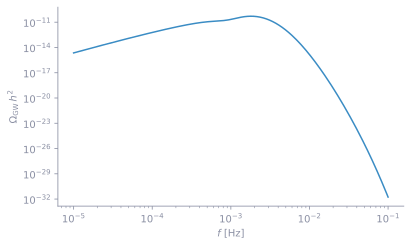

In [4]:
f = jnp.geomspace(1e-5, 1e-1, 200)
omega = model(f, *params)   # == model(f, logAs=-2.5, logDelta=-0.30103, logks=-2.0)

plt.loglog(f, omega)
plt.xlabel("$f$ [Hz]")
plt.ylabel(r"$\Omega_{\mathrm{GW}}\,h^2$");

### What the knobs do

* **`logAs`** scales the whole signal: $\Omega_{\mathrm{GW}}\propto A_s^2$ (two powers of
  $\mathcal{P}_\zeta$ enter the source).
* **`logks`** slides the GW bump in frequency (the GW peak tracks $k_\star$).
* **`logDelta`** sets how broad the bump is.

Next: the [components tour](advanced_example.ipynb) — the perturbation, kernel and
integrator options, and the inference interface.